In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report


In [2]:
import tensorflow as tf
# Check GPU availability
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("GPU Devices: ", tf.config.list_physical_devices('GPU'))

# Force GPU usage (if available)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✓ GPU enabled for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(e)
else:
    print("⚠ No GPU found - running on CPU")

Num GPUs Available:  1
GPU Devices:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✓ GPU enabled for 1 GPU(s)


In [3]:
train_dir = '/Users/shashidharhegde/Developer/DeepLearning/Arecanut/Arecanut_dataset/Arecanut_dataset/train'
val_dir = '/Users/shashidharhegde/Developer/DeepLearning/Arecanut/Arecanut_dataset/Arecanut_dataset/test'
test_dir = '/Users/shashidharhegde/Developer/DeepLearning/Arecanut/final_testing-20230830T042904Z-001/final_testing'
img_size = (224,224)
batch_size = 32 

train_ds_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    seed = 42,
    shuffle = True, 
    image_size = img_size,
    batch_size = batch_size
)

val_ds_data = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    seed = 42,
    shuffle = True, 
    image_size = img_size,
    batch_size = batch_size
)

test_ds_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    seed = 42,
    shuffle = True, 
    image_size = img_size,
    batch_size = batch_size
)

Found 8847 files belonging to 9 classes.
Found 2216 files belonging to 9 classes.
Found 1229 files belonging to 9 classes.


2026-05-06 19:01:30.493517: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-05-06 19:01:30.493546: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-06 19:01:30.493555: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-06 19:01:30.493586: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-06 19:01:30.493601: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [4]:
print('dataset size')
print(f'Train data size: {len(train_ds_data)}')
print(f'Val data size: {len(val_ds_data)}')

dataset size
Train data size: 277
Val data size: 70


In [5]:
print('dataset class names :\n')
display(train_ds_data.class_names)

dataset class names :



['Healthy_Leaf',
 'Healthy_Nut',
 'Healthy_Trunk',
 'Mahali_Koleroga',
 'Stem_bleeding',
 'bud borer',
 'healthy_foot',
 'stem cracking',
 'yellow leaf disease']

In [6]:
for image_batch, label_batch in train_ds_data.take(1):
    print(image_batch.shape)
    print(label_batch.shape)

(32, 224, 224, 3)
(32,)


2026-05-06 19:01:32.239230: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
from collections import Counter

class_names = train_ds_data.class_names
label_counter = Counter()

for images, labels in train_ds_data:
    label_counter.update(labels.numpy())

# print result
for label, count in label_counter.items():
    print(f"{class_names[label]}: {count}")

stem cracking: 540
Healthy_Trunk: 1432
Mahali_Koleroga: 2563
yellow leaf disease: 1477
Healthy_Leaf: 604
Healthy_Nut: 1886
bud borer: 144
healthy_foot: 50
Stem_bleeding: 151


2026-05-06 19:01:40.953203: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


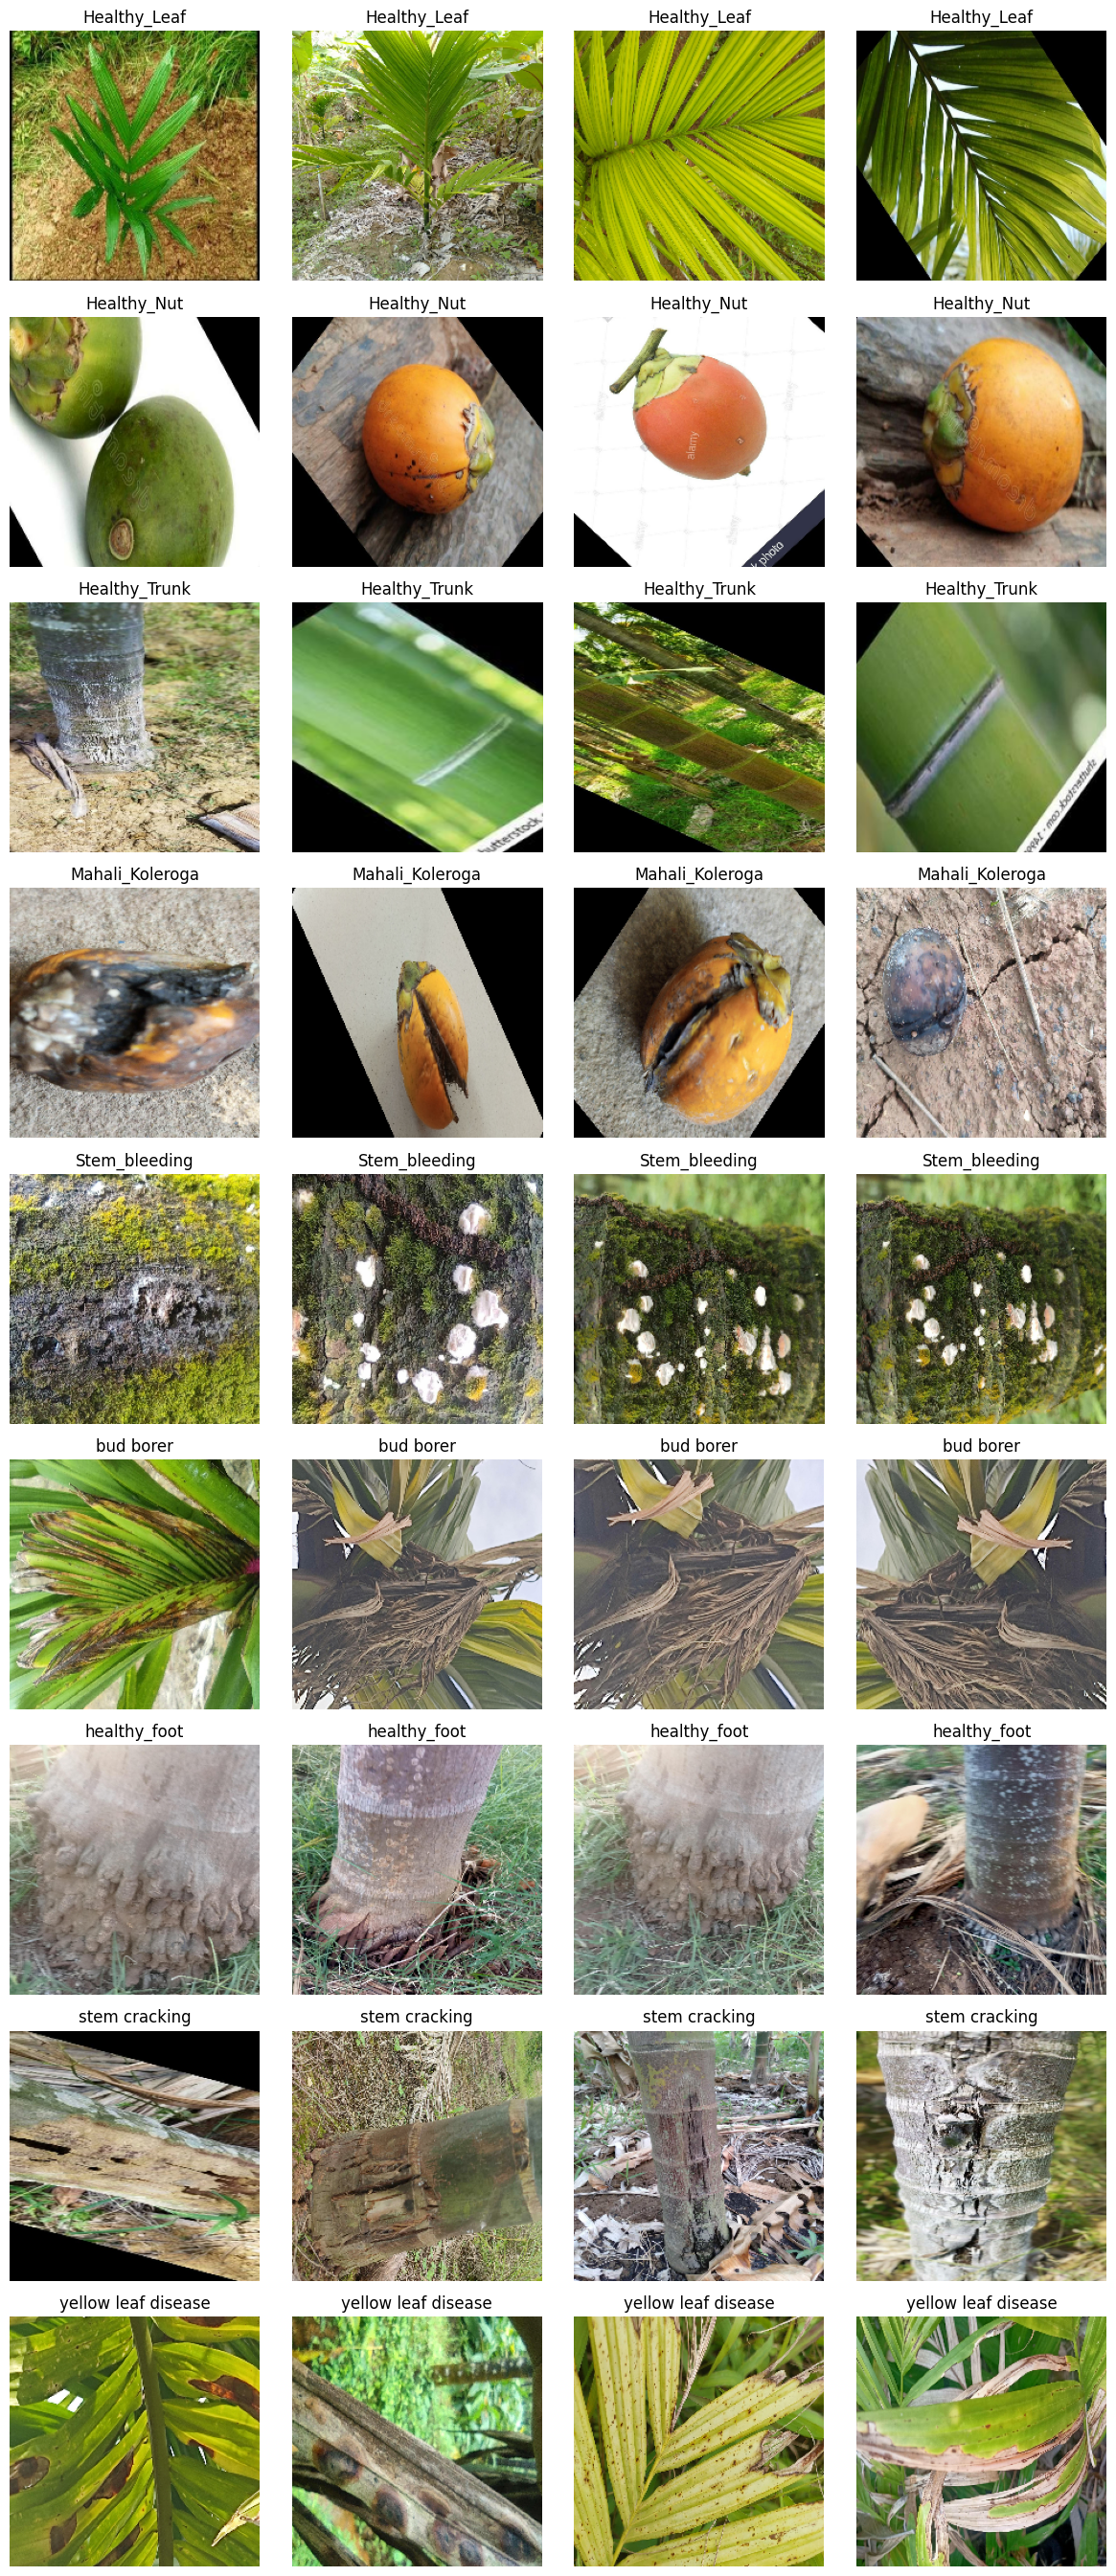

In [8]:
class_names = train_ds_data.class_names


class_images = {i: [] for i in range(len(class_names))}


for images, labels in train_ds_data:
    for i in range(len(labels)):
        label = labels[i].numpy()
        
        if len(class_images[label]) < 4:   
            class_images[label].append(images[i].numpy())
    

    if all(len(v) >= 4 for v in class_images.values()):
        break


plt.figure(figsize=(12, len(class_names)*3))

plot_index = 1
for class_idx, imgs in class_images.items():
    for img in imgs:
        plt.subplot(len(class_names), 4, plot_index)
        plt.imshow(img.astype("uint8"))
        plt.title(class_names[class_idx])
        plt.axis("off")
        plot_index += 1

plt.tight_layout()
plt.show()

In [9]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = []

for _, y in train_ds_data:
    labels.extend(y.numpy())

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

2026-05-06 19:01:51.160477: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [10]:
class_names = train_ds_data.class_names

In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds_data.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds_data.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds_data.cache().prefetch(buffer_size=AUTOTUNE)

In [12]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip('horizontal'),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(0.2),
        tf.keras.layers.RandomContrast(0.2),
        tf.keras.layers.RandomBrightness(0.2),
    ]
)

In [13]:
base_model = tf.keras.applications.ResNet50(
    weights = 'imagenet',
    include_top = False,
    input_shape = (224,224,3)
)

base_model.trainable = False

In [18]:
model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    base_model, 

    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    # layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

In [19]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [20]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3)
]

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 30,
    callbacks = callbacks,
    # class_weight = class_weights
)

Epoch 1/30


2026-05-06 17:03:20.760843: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


277/277 ━━━━━━━━━━━━━━━━━━━━ 95s 292ms/step - accuracy: 0.4459 - loss: 1.5983 - val_accuracy: 0.4120 - val_loss: 1.5246 - learning_rate: 1.0000e-04
Epoch 2/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 88s 317ms/step - accuracy: 0.5420 - loss: 1.2735 - val_accuracy: 0.5505 - val_loss: 1.2467 - learning_rate: 1.0000e-04
Epoch 3/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 85s 307ms/step - accuracy: 0.5657 - loss: 1.2087 - val_accuracy: 0.6020 - val_loss: 1.2140 - learning_rate: 1.0000e-04
Epoch 4/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 82s 297ms/step - accuracy: 0.5858 - loss: 1.1509 - val_accuracy: 0.6264 - val_loss: 1.1437 - learning_rate: 1.0000e-04
Epoch 5/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 81s 292ms/step - accuracy: 0.5957 - loss: 1.1390 - val_accuracy: 0.6358 - val_loss: 1.1601 - learning_rate: 1.0000e-04
Epoch 6/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 82s 295ms/step - accuracy: 0.5942 - loss: 1.1374 - val_accuracy: 0.6029 - val_loss: 1.2244 - learning_rate: 1.0000e-04
Epoch 7/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 83s 299ms/step - 

In [21]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

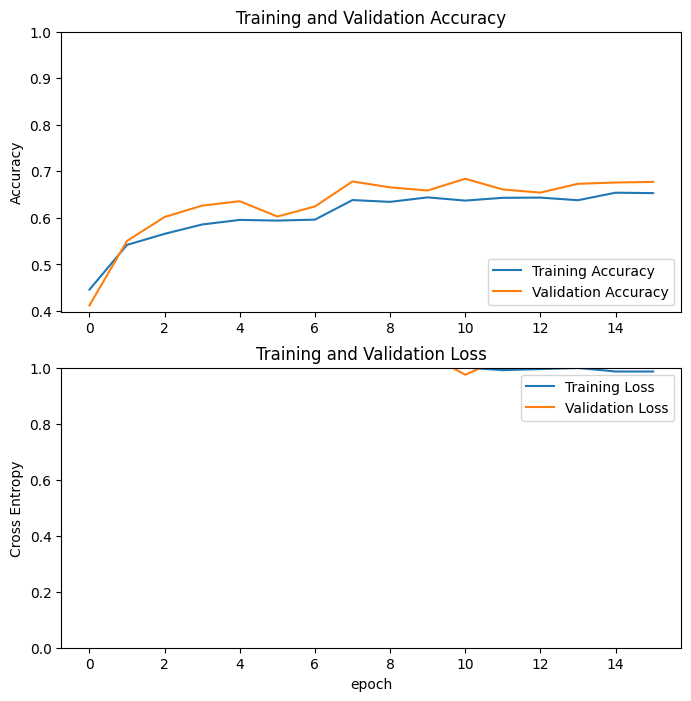

In [22]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [23]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)


history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 30,
    callbacks = callbacks,
    # class_weight = class_weights
)

Epoch 1/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 117s 395ms/step - accuracy: 0.4189 - loss: 2.4825 - val_accuracy: 0.3777 - val_loss: 3.1483 - learning_rate: 1.0000e-05
Epoch 2/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 105s 379ms/step - accuracy: 0.4884 - loss: 1.9152 - val_accuracy: 0.5194 - val_loss: 1.8319 - learning_rate: 1.0000e-05
Epoch 3/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 104s 374ms/step - accuracy: 0.5100 - loss: 1.7221 - val_accuracy: 0.5230 - val_loss: 1.7724 - learning_rate: 1.0000e-05
Epoch 4/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 100s 361ms/step - accuracy: 0.5393 - loss: 1.5679 - val_accuracy: 0.5749 - val_loss: 1.5237 - learning_rate: 1.0000e-06
Epoch 5/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 101s 366ms/step - accuracy: 0.5534 - loss: 1.4624 - val_accuracy: 0.5727 - val_loss: 1.5105 - learning_rate: 1.0000e-06


In [24]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

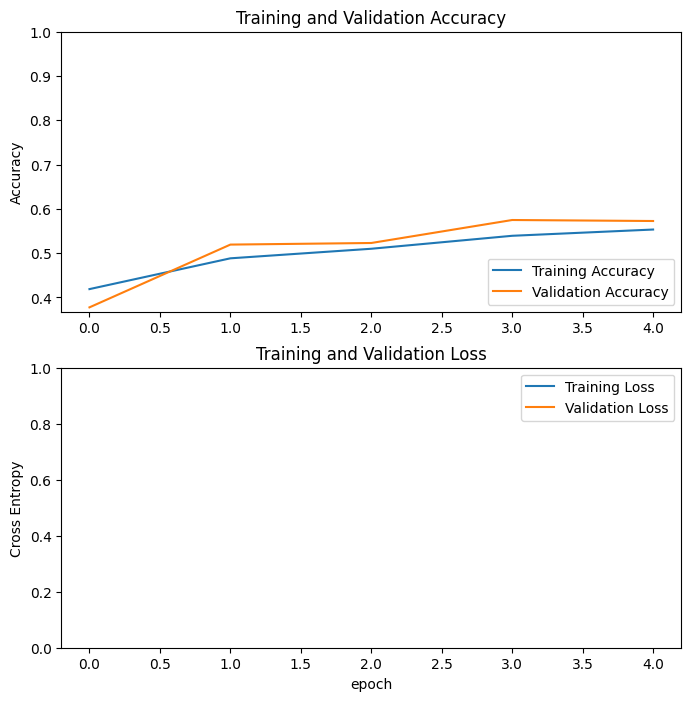

In [25]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [26]:
loss, acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {acc}")

 1/70 ━━━━━━━━━━━━━━━━━━━━ 16s 245ms/step - accuracy: 0.4062 - loss: 3.1171

70/70 ━━━━━━━━━━━━━━━━━━━━ 14s 199ms/step - accuracy: 0.3777 - loss: 3.1483
Validation Accuracy: 0.3777075707912445


In [18]:
def compile_model(model, learning_rate):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )


def make_fit_callbacks(model_name, save_best=False):
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1),
    ]
    if save_best:
        callbacks.append(
            ModelCheckpoint(
                f'best_disease_{model_name}.keras',
                monitor='val_accuracy',
                mode='max',
                save_best_only=True,
            )
        )
    return callbacks


def build_custom_cnn_hypermodel(hp):
    inputs = layers.Input(shape=(224, 224, 3))

    x = data_augmentation(inputs)
    x = layers.Rescaling(1./255)(x)

    num_conv_blocks = hp.Choice('conv_blocks', [4, 5, 6])
    filter_options = [32, 64, 128, 256]

    prev_filters = hp.Choice('filters_1', [16, 32])
    x = layers.Conv2D(
        prev_filters,
        3,
        padding='same',
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(1e-4),
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    for block_index in range(1, num_conv_blocks):
        max_next = min(prev_filters * 2, 256)
        valid_filters = [f for f in filter_options if prev_filters <= f <= max_next]
        # Fallback: if no valid filters, use prev_filters or smallest option >= prev_filters
        if not valid_filters:
            valid_filters = [f for f in filter_options if f >= prev_filters] or [256]
        filters = hp.Choice(f'filters_{block_index + 1}', valid_filters)

        x = layers.Conv2D(
            filters,
            3,
            padding='same',
            activation='relu',
            kernel_regularizer=tf.keras.regularizers.l2(1e-4),
        )(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)
        prev_filters = filters

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(hp.Choice('dense_units', [128, 256, 512]), activation='relu')(x)
    x = layers.Dropout(hp.Float('dropout_rate', 0.2, 0.5, step=0.1))(x)
    outputs = layers.Dense(len(class_names), activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='custom_cnn')
    compile_model(model, hp.Float('lr', 1e-4, 1e-2, sampling='log'))
    return model

In [19]:
num_classes = len(class_names)
custom_tuner = kt.RandomSearch(
    build_custom_cnn_hypermodel,
    objective='val_accuracy',
    max_trials=8,
    directory='disease_tuning',
    project_name='custom_cnn',
)

custom_tuner.search(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=make_fit_callbacks('custom_cnn_search'),
    class_weight=class_weights,
)

custom_tuner.results_summary()
custom_best_hp = custom_tuner.get_best_hyperparameters(num_trials=1)[0]
print('Best custom CNN hyperparameters:', custom_best_hp.values)

Trial 8 Complete [00h 07m 15s]
val_accuracy: 0.7441335916519165

Best val_accuracy So Far: 0.8632671236991882
Total elapsed time: 01h 51m 42s
Results summary
Results in disease_tuning/custom_cnn
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 1 summary
Hyperparameters:
conv_blocks: 6
filters_1: 32
filters_2: 32
filters_3: 64
filters_4: 32
dense_units: 512
dropout_rate: 0.2
lr: 0.0003031375640856382
filters_5: 128
filters_6: 128
Score: 0.8632671236991882

Trial 0 summary
Hyperparameters:
conv_blocks: 5
filters_1: 16
filters_2: 32
filters_3: 64
filters_4: 64
dense_units: 512
dropout_rate: 0.2
lr: 0.00023694782125688454
filters_5: 64
Score: 0.8307761549949646

Trial 6 summary
Hyperparameters:
conv_blocks: 5
filters_1: 16
filters_2: 32
filters_3: 64
filters_4: 64
dense_units: 128
dropout_rate: 0.4
lr: 0.00019790313757520978
filters_5: 64
filters_6: 128
Score: 0.7761732935905457

Trial 3 summary
Hyperparameters:
conv_blocks: 5
filters_1: 32
filters_2: 32
filter

In [21]:
EPOCHS = 50

custom_model = custom_tuner.get_best_models(num_models=1)[0]
custom_model.summary()

custom_history = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=make_fit_callbacks('custom_cnn_final', save_best=True),
    class_weight=class_weights,
)

custom_loss, custom_acc = custom_model.evaluate(test_ds, verbose=0)
print(f'Custom CNN test loss: {custom_loss:.4f}')
print(f'Custom CNN test accuracy: {custom_acc:.4f}')

model = custom_model

/opt/anaconda3/envs/datascience/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             

 Total params: 304,009 (1.16 MB)

 Trainable params: 303,177 (1.16 MB)

 Non-trainable params: 832 (3.25 KB)

Epoch 1/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 78s 245ms/step - accuracy: 0.8369 - loss: 0.4984 - val_accuracy: 0.7717 - val_loss: 0.7833 - learning_rate: 3.0314e-04
Epoch 2/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 66s 236ms/step - accuracy: 0.8465 - loss: 0.4633 - val_accuracy: 0.7252 - val_loss: 0.9804 - learning_rate: 3.0314e-04
Epoch 3/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 58s 209ms/step - accuracy: 0.8380 - loss: 0.5148 - val_accuracy: 0.7437 - val_loss: 0.9433 - learning_rate: 3.0314e-04
Epoch 4/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 60s 216ms/step - accuracy: 0.8832 - loss: 0.3446 - val_accuracy: 0.8651 - val_loss: 0.4921 - learning_rate: 3.0314e-04
Epoch 5/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 61s 220ms/step - accuracy: 0.8690 - loss: 0.4314 - val_accuracy: 0.7802 - val_loss: 0.8468 - learning_rate: 3.0314e-04
Epoch 6/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 61s 221ms/step - accuracy: 0.8548 - loss: 0.4717 - val_accuracy: 0.7658 - val_loss: 0.8932 - learning_rate: 3.0314e-04
Epoch 7/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 209

In [22]:
custom_model.save('arecanut_disease_custom_cnn.keras')
print('Saved custom CNN model.')

Saved custom CNN model.


Epoch 1/15
277/277 ━━━━━━━━━━━━━━━━━━━━ 63s 203ms/step - accuracy: 0.8015 - loss: 0.9799 - val_accuracy: 0.9206 - val_loss: 0.2930 - learning_rate: 0.0010
Epoch 2/15
277/277 ━━━━━━━━━━━━━━━━━━━━ 51s 185ms/step - accuracy: 0.8901 - loss: 0.5058 - val_accuracy: 0.9449 - val_loss: 0.2155 - learning_rate: 0.0010
Epoch 3/15
277/277 ━━━━━━━━━━━━━━━━━━━━ 46s 166ms/step - accuracy: 0.9012 - loss: 0.4291 - val_accuracy: 0.9553 - val_loss: 0.1760 - learning_rate: 0.0010
Epoch 4/15
277/277 ━━━━━━━━━━━━━━━━━━━━ 45s 162ms/step - accuracy: 0.9118 - loss: 0.4170 - val_accuracy: 0.9427 - val_loss: 0.2163 - learning_rate: 0.0010
Epoch 5/15
277/277 ━━━━━━━━━━━━━━━━━━━━ 44s 160ms/step - accuracy: 0.9200 - loss: 0.3772 - val_accuracy: 0.9522 - val_loss: 0.1813 - learning_rate: 0.0010
Epoch 6/15
277/277 ━━━━━━━━━━━━━━━━━━━━ 47s 168ms/step - accuracy: 0.9281 - loss: 0.3531 - val_accuracy: 0.9653 - val_loss: 0.1631 - learning_rate: 0.0010
Epoch 7/15
277/277 ━━━━━━━━━━━━━━━━━━━━ 44s 160ms/step - accuracy: 0.9

2026-05-06 23:44:47.622963: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Custom CNN Validation confusion matrix:
[[145   0   4   0   0   0   0   3   0]
 [  0 471   1   0   0   0   0   0   0]
 [  5   0 342   0   0   0   0   8   4]
 [  1   9   7 594   0  11   0  17   2]
 [  0   0   3   0  31   0   0   4   0]
 [  0   0   3   0   0  30   0   2   1]
 [  0   0   0   0   0   0  13   0   0]
 [  0   0   4   0   0   2   3 126   0]
 [ 28   0  21   0   0   0   0   2 319]]
                     precision    recall  f1-score   support

       Healthy_Leaf       0.81      0.95      0.88       152
        Healthy_Nut       0.98      1.00      0.99       472
      Healthy_Trunk       0.89      0.95      0.92       359
    Mahali_Koleroga       1.00      0.93      0.96       641
      Stem_bleeding       1.00      0.82      0.90        38
          bud borer       0.70      0.83      0.76        36
       healthy_foot       0.81      1.00      0.90        13
      stem cracking       0.78      0.93      0.85       135
yellow leaf disease       0.98      0.86      0.92       

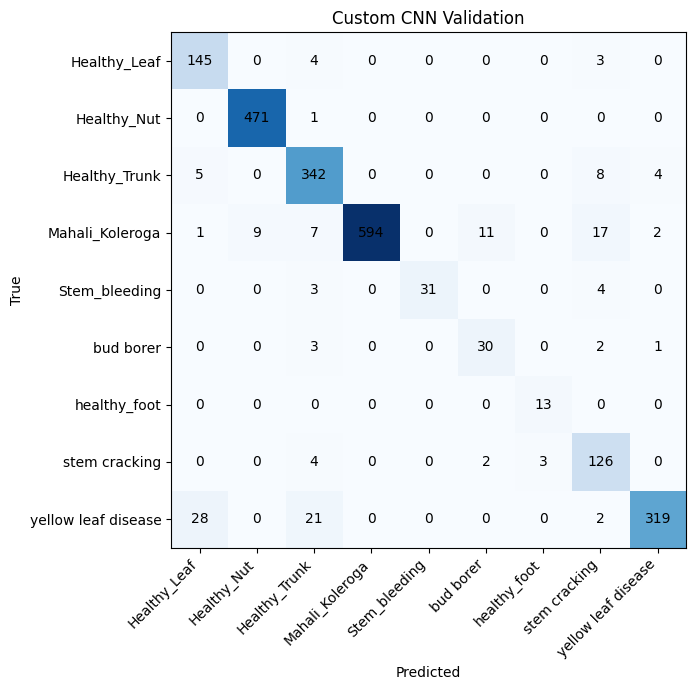


MobileNetV2 Validation confusion matrix:
[[151   0   0   0   0   0   0   0   1]
 [  0 472   0   0   0   0   0   0   0]
 [  1   0 351   0   1   0   0   6   0]
 [  0   3   2 636   0   0   0   0   0]
 [  0   0   0   0  38   0   0   0   0]
 [  0   0   0   0   0  36   0   0   0]
 [  0   0   0   0   0   0  13   0   0]
 [  0   0   3   0   1   0   0 131   0]
 [ 14   0   5   0   0   0   0   5 346]]
                     precision    recall  f1-score   support

       Healthy_Leaf       0.91      0.99      0.95       152
        Healthy_Nut       0.99      1.00      1.00       472
      Healthy_Trunk       0.97      0.98      0.97       359
    Mahali_Koleroga       1.00      0.99      1.00       641
      Stem_bleeding       0.95      1.00      0.97        38
          bud borer       1.00      1.00      1.00        36
       healthy_foot       1.00      1.00      1.00        13
      stem cracking       0.92      0.97      0.95       135
yellow leaf disease       1.00      0.94      0.97      

2026-05-06 23:44:59.188046: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


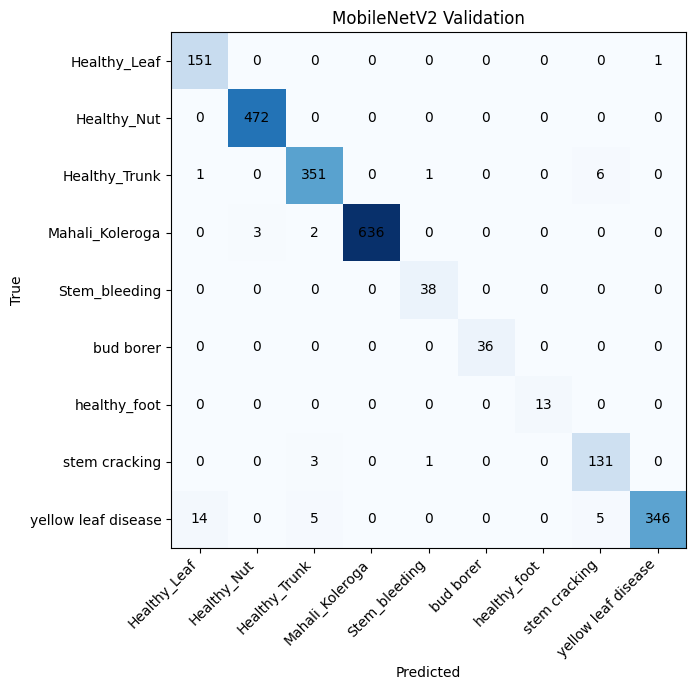

In [23]:
def show_confusion_matrix(model, dataset, title):
    y_prob = model.predict(dataset, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = np.concatenate([y.numpy() for _, y in dataset], axis=0)

    cm = confusion_matrix(y_true, y_pred)
    print(f'\n{title} confusion matrix:')
    print(cm)
    print(classification_report(y_true, y_pred, target_names=class_names))

    plt.figure(figsize=(8, 7))
    plt.imshow(cm, cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
    plt.yticks(range(len(class_names)), class_names)

    for row_index in range(cm.shape[0]):
        for col_index in range(cm.shape[1]):
            plt.text(col_index, row_index, cm[row_index, col_index], ha='center', va='center', color='black')

    plt.tight_layout()
    plt.show()


def build_mobilenetv2_model():
    inputs = layers.Input(shape=(224, 224, 3))

    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

    base_model = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3),
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(len(class_names), activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='mobilenetv2_disease')
    return model, base_model


mobilenet_model, mobilenet_base_model = build_mobilenetv2_model()
compile_model(mobilenet_model, 1e-3)

mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=make_fit_callbacks('mobilenet_head', save_best=True),
    class_weight=class_weights,
)

mobilenet_base_model.trainable = True
for layer in mobilenet_base_model.layers[:-30]:
    layer.trainable = False

compile_model(mobilenet_model, 1e-5)
mobilenet_finetune_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=make_fit_callbacks('mobilenet_finetuned', save_best=True),
    class_weight=class_weights,
)

mobilenet_loss, mobilenet_acc = mobilenet_model.evaluate(test_ds, verbose=0)
print(f'MobileNetV2 test loss: {mobilenet_loss:.4f}')
print(f'MobileNetV2 test accuracy: {mobilenet_acc:.4f}')

show_confusion_matrix(custom_model, val_ds, 'Custom CNN Validation')
show_confusion_matrix(mobilenet_model, val_ds, 'MobileNetV2 Validation')

mobilenet_model.save('arecanut_disease_mobilenetv2.keras')